# DATA PREPROCESSING PART 

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("Amazon.csv")

### DATA PREPARATION & FEATURED ENGINEERING

# Change OrderDate to datetime
print("Data type before changing to datetime:",df["OrderDate"].dtype)      
df["OrderDate"]=pd.to_datetime(df["OrderDate"])
print("\nData type after changing to datetime:",df["OrderDate"].dtype)   

# changing the state name form
state_map = {
    "TX": "Texas",
    "CA": "California",
    "NC": "North Carolina",
    "FL": "Florida",
    "WA": "Washington",
    "OH": "Ohio",
    "DC": "District of Columbia",
    "IL": "Illinois",
    "PA": "Pennsylvania",
    "CO": "Colorado",
    "IN": "Indiana",
    "NY": "New York",
    "AZ": "Arizona"
}
df["State"]=df["State"].replace(state_map)
print("\nafter changing state name:\n",df["State"])

# adding year and month column

df["Year"]=df["OrderDate"].dt.year
df["Month"]=df["OrderDate"].dt.month

Data type before changing to datetime: object

Data type after changing to datetime: datetime64[ns]

after changing state name:
 0        District of Columbia
1                       Texas
2                       Texas
3              North Carolina
4                       Texas
                 ...         
99995                 Florida
99996              California
99997                 Indiana
99998          North Carolina
99999                New York
Name: State, Length: 100000, dtype: object


# QUANTITY PREDICTION MODEL 
--- PREDICT QUANTITY USING LINEAR REGRESSION ---

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df_label=df.copy()
le=LabelEncoder()
df_label["Brand Encoder"]=le.fit_transform(df_label["Brand"])
df_label["Category Encoder"]=le.fit_transform(df_label["Category"])
df_label["Payment method Encoder"]=le.fit_transform(df_label["PaymentMethod"])
df_label["Country Encoder"]=le.fit_transform(df_label["Country"])

features=["UnitPrice","Discount","Brand Encoder","Category Encoder","Tax","ShippingCost","Payment method Encoder","Country Encoder","Month"]
X=df_label[features]
y=df_label["Quantity"]

X_train, X_test, Y_train, Y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model=LinearRegression()
model.fit(X_train,Y_train)
y_pred=model.predict(X_test)
mae=mean_absolute_error(Y_test,y_pred)
mse=mean_squared_error(Y_test,y_pred)
r2=r2_score(Y_test,y_pred)
print("The quantity prediction is:",y_pred)
print("Intercept:",model.intercept_)
print("Coefficient:")
for feat,coef in zip(features,model.coef_):
    print(f"{feat}:{coef:.2f}")
print("MAE",mae.__round__(2))
print("MSE",mse.__round__(2))
print("r2",r2.__round__(3))

The quantity prediction is: [2.2220385  2.83535268 3.01335394 ... 2.99224555 2.8415878  3.01848186]
Intercept: 2.86377537714492
Coefficient:
UnitPrice:-0.00
Discount:0.84
Brand Encoder:0.00
Category Encoder:0.01
Tax:0.01
ShippingCost:0.01
Payment method Encoder:-0.00
Country Encoder:-0.00
Month:0.00
MAE 1.02
MSE 1.47
r2 0.263


# VISUALIZATION FOR LINEAR REGRESSION MODEL
- Showing a scatter plot for actual vs predicted value and the prediction line.

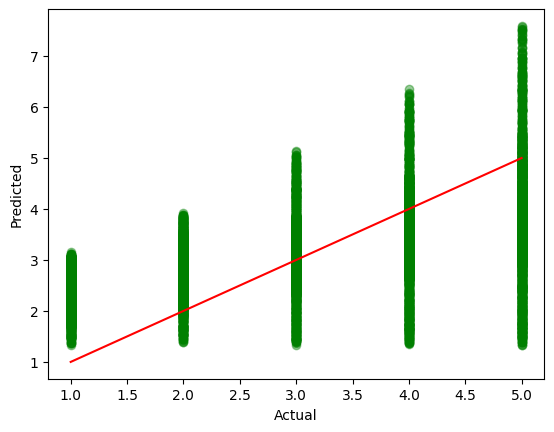

In [13]:
plt.scatter(Y_test,y_pred,color="green",alpha=0.4)
plt.plot([Y_test.min(),Y_test.max()],[Y_test.min(),Y_test.max()],color="red")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

# KNN Regressor model for quantity prediction

In [14]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

df_encoded=pd.get_dummies(df, columns=["Brand","Category","PaymentMethod","Country"])

X=df_encoded.drop(columns=['OrderID','OrderDate','CustomerID','CustomerName','ProductID',
                           'ProductName','OrderStatus','City','State','SellerID','Year'],axis=1)
y=df_encoded["Quantity"]

X_train, X_test, Y_train, Y_test=train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model=KNeighborsRegressor(n_neighbors=3)
model.fit(X_train_scaled,Y_train)
y_pred=model.predict(X_test_scaled)
mae=mean_absolute_error(Y_test,y_pred)
mse=mean_squared_error(Y_test,y_pred)
r2=r2_score(Y_test,y_pred)
print("\nPredictions by KNN Regressor model are:\n",y_pred)
print("MAE",mae.__round__(2))
print("MSE",mse.__round__(2))
print("r2",r2.__round__(3))


Predictions by KNN Regressor model are:
 [2.66666667 2.         4.         ... 2.66666667 1.         3.66666667]
MAE 0.44
MSE 0.37
r2 0.816


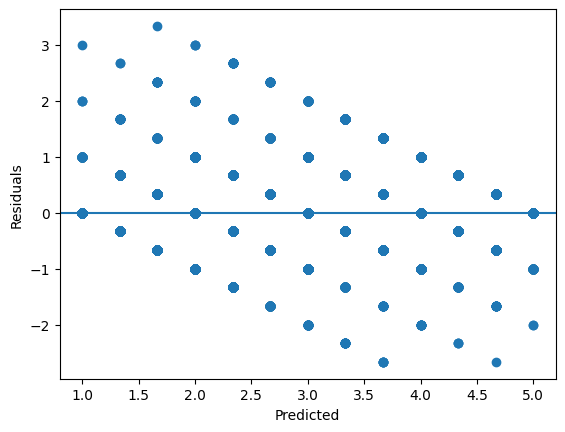

In [15]:
residuals = Y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show() 

# K2 vs Error Plot

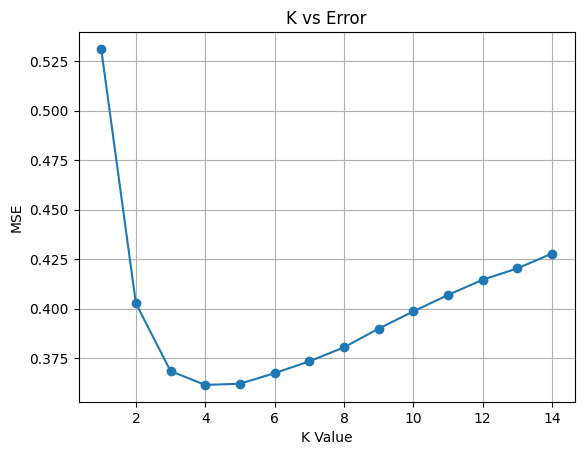

In [16]:
errors = []

for k in range(1, 15):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train_scaled, Y_train)
    y_pred = model.predict(X_test_scaled)
    mse = mean_squared_error(Y_test, y_pred)
    errors.append(mse)

plt.figure()
plt.plot(range(1, 15), errors, marker="o")
plt.xlabel("K Value")
plt.ylabel("MSE")
plt.title("K vs Error")
plt.grid()
plt.show()